# Graph Neural Network for GlueX forward calo data - Tutorial

In [1]:
# %pip -q install uproot awkward torch-geometric scikit-learn safetensors tqdm > /dev/null
%pip install -q uproot awkward scikit-learn safetensors tqdm
%pip install -q torch-geometric
%pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.10.0+cu128.html

In [2]:
import torch
import torch_scatter
import torch_geometric

print(torch.__version__)
print(torch_scatter.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA:", torch.version.cuda)

2.10.0+cu128
2.1.2+pt210cu128
CUDA available: True
CUDA: 12.8


In [3]:
!uname -a

Linux 3d4f44b3b7e7 6.6.113+ #1 SMP Mon Feb  2 12:27:57 UTC 2026 x86_64 x86_64 x86_64 GNU/Linux


In [4]:
!nvidia-smi

Wed Mar 11 01:38:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Data

### Download unformatted particle-gun ROOT (for GNN)

In [5]:
import os
from urllib.parse import urlparse
import urllib.request
from tqdm import tqdm

class DownloadProgressBar(tqdm):
    """Custom TQDM progress bar for urllib downloads."""
    def update_to(self, blocks=1, block_size=1, total_size=None):
        """
        Update the progress bar.

        Args:
            blocks (int): Number of blocks transferred so far.
            block_size (int): Size of each block (in bytes).
            total_size (int, optional): Total size of the file (in bytes).
        """
        if total_size is not None:
            self.total = total_size
        self.update(blocks * block_size - self.n)


def download(url, target_dir):
    """
    Download a file from a URL into the target directory with progress display.

    Args:
        url (str): Direct URL to the file.
        target_dir (str): Directory to save the file.

    Returns:
        str: Path to the downloaded (or existing) file.
    """
    # Ensure the target directory exists
    os.makedirs(target_dir, exist_ok=True) #do nothing if target_dir exists

    # Infer the filename from the URL
    filename = os.path.basename(urlparse(url).path) # parse the url (scheme, netloc, path) and take the name of the file
    local_path = os.path.join(target_dir, filename)

    # If file already exists, skip download
    if os.path.exists(local_path):
        print(f"\n✅ File already exists: {local_path}\n")
        return local_path

    # Download with progress bar
    print(f"\n⬇️  Downloading {filename} from {url}\n")

    with DownloadProgressBar(unit='B', unit_scale=True, miniters=1, desc=filename) as t: #miniters controls how frequently tqdm updates the bar
        urllib.request.urlretrieve(url, filename=local_path, reporthook=t.update_to)

    print(f"\n✅ Download complete: {local_path}\n")
    return local_path

data_dir = "data"

In [6]:
unformatted_particle_data_url = "https://huggingface.co/datasets/AI4EIC/DNP2025-tutorial/resolve/main/unformatted_dataset/ParticleGunDataSet_800k.root"
data_dir = "data"
gun_root = download(unformatted_particle_data_url, data_dir)


✅ File already exists: data/ParticleGunDataSet_800k.root



### Read ROOT arrays

In [7]:
import uproot, awkward as ak, numpy as np

file = uproot.open(gun_root)
file.keys()


['FCALShowers;1']

In [8]:
tree = uproot.open(gun_root)["FCALShowers"]

tree.keys()

['index',
 'thrownPID',
 'thrownEnergy',
 'thrownPosition_fX',
 'thrownPosition_fY',
 'thrownPosition_fZ',
 'thrownMomentum_fX',
 'thrownMomentum_fY',
 'thrownMomentum_fZ',
 'thrownMass',
 'numBlocks',
 'isNearBorder',
 'showerE',
 'showerPos_fX',
 'showerPos_fY',
 'showerPos_fZ',
 'nrows',
 'rows',
 'ncols',
 'cols',
 'nenergies',
 'energies',
 'isSplitOff',
 'isPhotonShower']

Explanation of these features can be found here:
[data preparation](https://ai4eic.github.io/APS2026_GPS_tutorials/notebooks/02-dataset-preparation.html)

In [9]:
branches = ["rows","cols","energies","showerE","thrownEnergy","numBlocks","isNearBorder","isSplitOff","isPhotonShower"]
arr = tree.arrays(branches, library="ak")

rows_ak, cols_ak, en_ak = arr["rows"], arr["cols"], arr["energies"]
showerE = ak.to_numpy(arr["showerE"]).astype(np.float32)
thrownE = ak.to_numpy(arr["thrownEnergy"]).astype(np.float32)
numBlocks = ak.to_numpy(arr["numBlocks"]).astype(np.int32)
isNearBorder = ak.to_numpy(arr["isNearBorder"]).astype(bool)
isSplit = ak.to_numpy(arr["isSplitOff"]).astype(bool)
isPhoton = ak.to_numpy(arr["isPhotonShower"]).astype(bool)

# Labels consistent with GNN: 1 photon, 0 splitOff
labels = np.where(isPhoton, 1, np.where(isSplit, 0, -1)).astype(np.int64)

# Keep only clean ones
keep = labels >= 0
keep_idx = np.where(keep)[0]

print("Total:", len(labels), "Kept:", len(keep_idx))
print("Photons:", np.sum(labels[keep_idx]==1), "SplitOffs:", np.sum(labels[keep_idx]==0))

Total: 814151 Kept: 814151
Photons: 434845 SplitOffs: 379306


### Train/Val/Test Split

In [10]:
from sklearn.model_selection import train_test_split

indices = keep_idx
y = labels[indices]

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=y, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=labels[temp_idx], random_state=42)

# class counts (for weighting)
n_ph = np.sum(labels[train_idx] == 1)
n_so = np.sum(labels[train_idx] == 0)
counts = np.array([n_so, n_ph], dtype=np.float32)   # [splitOff, photon]
counts

array([265514., 304391.], dtype=float32)

## 2. Graph Construction

### Graph Construction (all hits)

**Data Engineering**

Typical pattern in a shower:

* central blocks -> large energy

* nearby blocks -> moderate

* peripheral blocks -> very small

Consequently, if you feed raw energies directly into a neural network:

* large values fominate gradients

* tiny values become almost invisible

* training could become unstable




We do a node-level energy transform

$$
z(E) = \frac{log(1+E/e_{0})}{log(1+E_{max}/e_{0})} \in [0,1]
$$

We are applying a non-linear compression of the energy scale

* large energies -> compressed

* small energies -> expanded

This could make the shape of the shower easier to learn. In calorimeter ML this is very common.

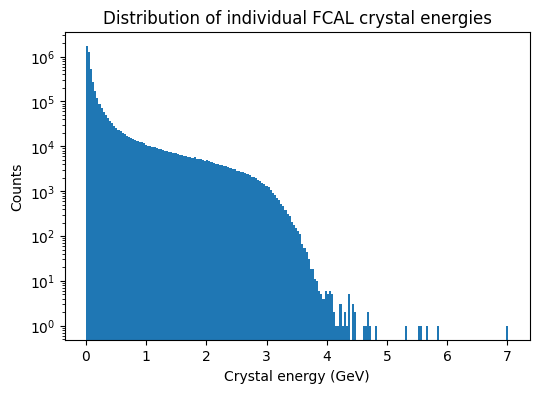

In [11]:
import matplotlib.pyplot as plt

# Flatten all crystal energies across all showers
all_E = ak.to_numpy(ak.flatten(en_ak))

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(all_E, bins=200)
plt.xlabel("Crystal energy (GeV)")
plt.ylabel("Counts")
plt.title("Distribution of individual FCAL crystal energies")
plt.yscale("log")   # useful because distribution spans many orders
plt.show()

In [12]:
np.quantile(all_E, [0.9, 0.95, 0.99, 0.999])

array([0.53997727, 1.16369786, 2.37762243, 3.12767875])

In [13]:
import torch
from torch_geometric.data import Data

FCAL_GEOMETRY = (59, 59)
ENERGY_SCALE  = 0.05 #
CLIP_MAX      = 2.0 #

#############################################################################################################
# nodes = calorimeter blocks belonging to the shower
# edges = adjacency between neighboring blocks
# node features = per-block quantities like position and energy
# global graph features = shower-level quantities like total shower energy, number of blocks, and border flag
#############################################################################################################
def logE_norm(E, e0=ENERGY_SCALE, emax=CLIP_MAX, eps=1e-9):
    E = np.clip(E.astype(np.float32, copy=False), 0.0, emax)
    Z = np.log1p(E / np.float32(e0))
    Z = Z / np.log1p(np.float32(emax) / np.float32(e0))
    return np.clip(Z, 0.0, 1.0).astype(np.float32)

def build_edges_8n(rows, cols):
    # creates a dictionary mapping grid position → node index.
    # Later we want to ask: if crystal (r,c) has a neighbour at (r+1,c), which node is that?
    idx = {(int(r), int(c)): i for i, (r, c) in enumerate(zip(rows, cols))}

    neigh = [(-1,-1), (-1,0), (-1,1),
             ( 0,-1),         ( 0,1),
             ( 1,-1), ( 1,0), ( 1,1)]
    edges = []
    for i, (r, c) in enumerate(zip(rows, cols)):
        r = int(r); c = int(c)
        for dr, dc in neigh:
            j = idx.get((r+dr, c+dc), None)
            if j is not None:
                edges.append((i, j))
    if len(edges) == 0:
        return torch.empty((2, 0), dtype=torch.long)               # returns 2 x E, where E are edges
    return torch.tensor(edges, dtype=torch.long).t().contiguous()  # returns 2 x E
    # .contiguous forces PyTorch to copy the data into a new block of memory arranged in the correct order after transpose

#############################################################################################################
# the output of shower_to_graph is a torch_geometric.data.Data object representing one shower
#############################################################################################################
def shower_to_graph(rows, cols, energies, showerE, numBlocks, isNearBorder, eps=1e-9):
    rows = np.asarray(rows, dtype=np.int64)
    cols = np.asarray(cols, dtype=np.int64)
    Eraw = np.asarray(energies, dtype=np.float32)
    if len(Eraw) == 0:
        return None

    # Energy transform
    E = logE_norm(Eraw)

    Esum = float(Eraw.sum()) + eps  # use raw sum for fractions

    # Cluster "center of mass"
    # --- In FCAL, rows and cols are indices of position on the calorimeter plane. We can compute energy-weighted indices:
    row_c = float((rows * Eraw).sum() / Esum)
    col_c = float((cols * Eraw).sum() / Esum)

    # Relative coordinates: cluster shape
    dx = (rows - row_c).astype(np.float32)
    dy = (cols - col_c).astype(np.float32)
    rr = np.sqrt(dx*dx + dy*dy).astype(np.float32)

    # Normalize detector coordinates
    # rows 0->58
    # cols 0->58
    row_n = (rows.astype(np.float32) / (FCAL_GEOMETRY[0]-1)) * 2 - 1  #[0,1]->[-1,1]
    col_n = (cols.astype(np.float32) / (FCAL_GEOMETRY[1]-1)) * 2 - 1  #[0,1]->[-1,1]

    Efrac = (Eraw / Esum).astype(np.float32)
    logE  = np.log(Eraw + eps).astype(np.float32)

    # Node features
    # [row_n, col_n, E_logscaled, logEraw, Efrac, dx, dy, r] --- they all are (N,)
    x = np.stack([row_n, col_n, E, logE, Efrac, dx, dy, rr], axis=1).astype(np.float32) # --- returns (N, 8) where N: #crystals, 8: #features
    x = torch.tensor(x, dtype=torch.float32)

    edge_index = build_edges_8n(rows, cols)

    data = Data(x=x, edge_index=edge_index) # defines data.x and data.edge_index
    data.g = torch.tensor([float(showerE), float(numBlocks), float(isNearBorder)], dtype=torch.float32) #data.g is a custom attribute that stores graph-level (global) features for the shower
    return data

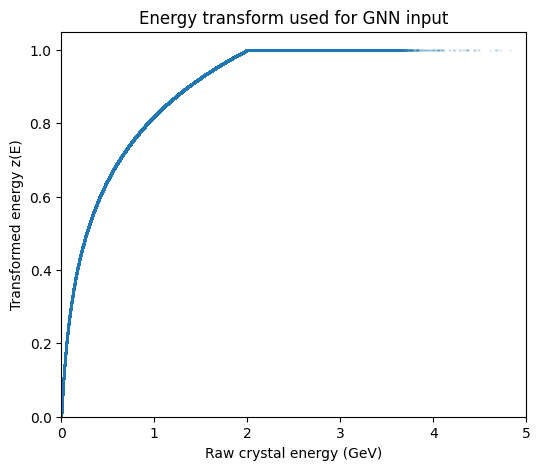

In [14]:
# flatten energies
all_E = ak.to_numpy(ak.flatten(en_ak))

# apply your transform
Z = logE_norm(all_E)

plt.figure(figsize=(6,5))
plt.scatter(all_E, Z, s=1, alpha=0.1)
plt.xlabel("Raw crystal energy (GeV)")
plt.ylabel("Transformed energy z(E)")
plt.title("Energy transform used for GNN input")
plt.xlim(0,5)
plt.ylim(0,1.05)
plt.show()

### Visualize Graphs

In [15]:
def plot_shower_nodes(rows, cols, energies=None, title="Shower nodes"):
    rows = np.asarray(rows)
    cols = np.asarray(cols)

    plt.figure(figsize=(6, 6))
    if energies is None:
        plt.scatter(cols, rows, s=80)
    else:
        sc = plt.scatter(cols, rows, c=energies, s=120)
        plt.colorbar(sc, label="Crystal energy")

    plt.gca().invert_yaxis()   # optional, often nicer for detector grids
    plt.xlabel("col")
    plt.ylabel("row")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.show()

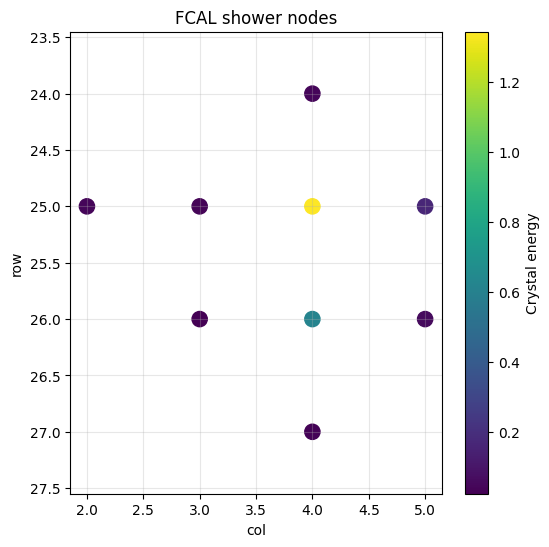

1


In [16]:
i = keep_idx[7879]
plot_shower_nodes(rows_ak[i], cols_ak[i], en_ak[i], title="FCAL shower nodes")
print(labels[i])

### Dataset + DataLoader

In [17]:
from torch.utils.data import Dataset
from torch_geometric.loader import DataLoader

class FCALGraphDataset(Dataset):
    def __init__(self, idx_list):
        self.idx = np.asarray(idx_list, dtype=np.int64)

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):

      j = int(self.idx[i])
      rows = ak.to_numpy(rows_ak[j])
      cols = ak.to_numpy(cols_ak[j])
      ens  = ak.to_numpy(en_ak[j])

      data = shower_to_graph(rows, cols, ens,
                            showerE=showerE[j],
                            numBlocks=numBlocks[j],
                            isNearBorder=isNearBorder[j])

      y = labels[j]  # 0/1
      data.y = torch.tensor([y], dtype=torch.long)

      # IMPORTANT: make graph-level features 2D so they batch correctly
      data.g = torch.tensor([[float(showerE[j]),
                              float(numBlocks[j]),
                              float(isNearBorder[j])]], dtype=torch.float32)

      # Optional metadata (also 2D is fine; 1D works, but keep consistent)
      data.showerE = torch.tensor([float(showerE[j])], dtype=torch.float32)
      data.thrownE = torch.tensor([float(thrownE[j])], dtype=torch.float32)

      return data

BATCH_SIZE = 512
train_loader = DataLoader(FCALGraphDataset(train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(FCALGraphDataset(val_idx), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(FCALGraphDataset(test_idx), batch_size=BATCH_SIZE, shuffle=False)

it = iter(train_loader)
batch1 = next(it)
print(batch1)
batch2 = next(it)
print(batch2)


DataBatch(x=[3153, 8], edge_index=[2, 11220], g=[512, 3], y=[512], showerE=[512], thrownE=[512], batch=[3153], ptr=[513])
DataBatch(x=[3168, 8], edge_index=[2, 11304], g=[512, 3], y=[512], showerE=[512], thrownE=[512], batch=[3168], ptr=[513])


**Notes:**

* `ptr` is a pointer array automatically created by the PyTorch Geometric DataLoader. It tells you where each graph starts and ends in the concatenated node list.

* Formally, `ptr.shape = batch_size + 1`

In [18]:
batch2.ptr

tensor([   0,   10,   14,   27,   29,   41,   53,   57,   67,   78,   81,   84,
          88,  100,  104,  108,  115,  123,  128,  130,  135,  141,  144,  147,
         151,  156,  160,  165,  176,  180,  184,  187,  195,  197,  203,  213,
         215,  221,  227,  232,  239,  245,  253,  264,  267,  274,  280,  283,
         285,  296,  304,  307,  314,  321,  324,  327,  333,  340,  344,  350,
         354,  362,  366,  371,  374,  378,  381,  383,  389,  398,  402,  407,
         410,  412,  415,  417,  428,  439,  444,  451,  455,  462,  464,  467,
         470,  482,  487,  490,  493,  499,  504,  510,  516,  522,  525,  532,
         537,  549,  553,  558,  562,  564,  570,  582,  587,  597,  600,  603,
         613,  618,  628,  631,  642,  656,  660,  667,  669,  678,  687,  691,
         701,  704,  714,  719,  722,  732,  736,  739,  748,  754,  758,  762,
         766,  777,  780,  790,  793,  798,  803,  810,  814,  824,  828,  835,
         839,  842,  844,  848,  856,  8

**Convert a PyG graph to NetworkX and plot**

In [19]:
from torch_geometric.utils import to_networkx
import networkx as nx

# take a single shower
i = keep_idx[7879]

rows = np.asarray(rows_ak[i])
cols = np.asarray(cols_ak[i])
ens  = np.asarray(en_ak[i])

data = shower_to_graph(rows, cols, ens,
                       showerE=showerE[i],
                       numBlocks=numBlocks[i],
                       isNearBorder=isNearBorder[i])

# convert to networkx
G = to_networkx(data, to_undirected=True)

Use detector coordinates for layout


In [20]:
pos = {i: (cols[i], rows[i]) for i in range(len(rows))}

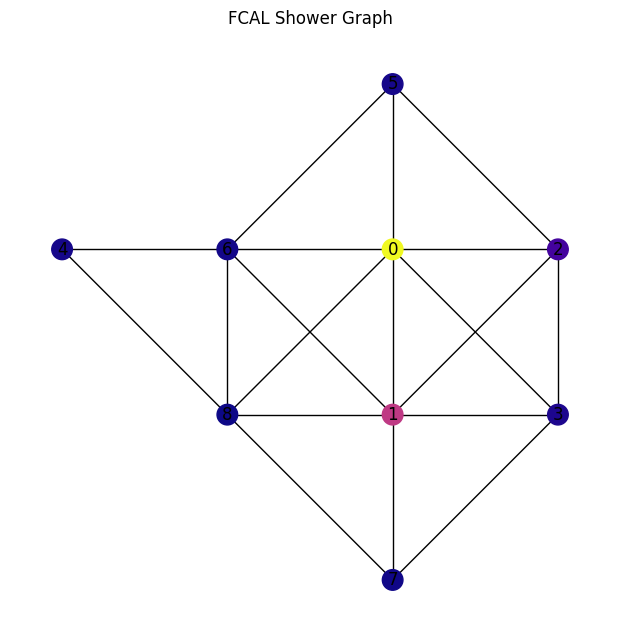

In [21]:
plt.figure(figsize=(6,6))

nx.draw(
    G,
    pos=pos,
    node_size=220,
    node_color=ens,
    cmap="plasma",
    with_labels=True
)

plt.gca().invert_yaxis()
plt.title("FCAL Shower Graph")
plt.show()

## 3. GNN Model

**To-do list**

* Explain GNN --- link to slides?

* Explain --- Explain SAGEConv and link to other types of graph neural networks

### GNN Model (graph classifier)

In [22]:
################################################################################
#                            MODEL DESCRIPTION                                 #
################################################################################
#	1.	crystals start with 8 handcrafted node features                          #
#	2.	GraphSAGE updates each crystal using neighboring crystals                #
#	3.	after 3 layers, each crystal embedding reflects local shower structure   #
#	4.	node embeddings are pooled into one vector representing the whole shower #
#	5.	that vector is combined with global shower metadata                      #
#	6.	final MLP predicts whether the shower is photon or split-off             #
################################################################################

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool

# (crystal/node features) x_i = [row_n, col_n, E, logE, Efrac, dx, dy, rr]
# (shower/graph features) [showerE, numBlocks, isNearBorder]

class SmallGNN(nn.Module):
    def __init__(self, node_in=8, g_in=3, hidden=64, n_classes=2, dropout=0.1):

        # node_in : number of input features per node (here 8 crystal features)
        # g_in    : number of graph-level features (here 3 shower-level quantities in data.g)
        # hidden  : size of the node embedding produced by the GNN layers
        # n_classes : number of output classes (photon vs split-off)
        # dropout : dropout probability used in the classification head

        super().__init__()
        # calls the constructor of the parent class (nn.Module)
        # this registers the model with PyTorch so parameters, layers,
        # and gradients are properly tracked during training

        # GraphSAGE layers (message passing between neighboring crystals)
        # N = total number of nodes in the batch

        self.conv1 = SAGEConv(node_in, 64)  # (N, node_in=8)  -> (N, 64)
        # each node updates its features by aggregating information from its neighbors

        self.conv2 = SAGEConv(64, 64)       # (N, 64) -> (N, 64)
        # deeper layer: node embeddings now encode information from a larger neighborhood

        self.conv3 = SAGEConv(64, hidden)   # (N, 64) -> (N, hidden)
        # final node embeddings used for graph-level pooling

        self.head = nn.Sequential(
            nn.Linear(2*hidden + g_in, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, data):

        # data.batch tells which graph each node belongs to. Its dimension, B, coincides with the total number of nodes in the batch, Ntot
        # x: (Ntot, 8); ei: (2, Etot); b: (Ntot,)
        x, ei, b = data.x, data.edge_index, data.batch

        #############################################################################
        # Node embedding stage:
        # start from crystal-level node features (8 per crystal)
        # each SAGEConv layer updates a crystal representation by combining
        # its own features with features aggregated from neighboring crystals
        # (defined by the graph edges)
        #############################################################################

        x = F.relu(self.conv1(x, ei))   # (Ntot, node_in=8)  -> (Ntot, 64)
        x = F.relu(self.conv2(x, ei))   # (Ntot, 64)         -> (Ntot, 64)
        x = F.relu(self.conv3(x, ei))   # (Ntot, 64)         -> (Ntot, hidden)

        #############################################################################
        # pool all node embeddings into one-grap-level embedding for the whole shower
        #############################################################################

        # B: number of graphs/showers in the batch
        pooled = torch.cat([global_mean_pool(x, b), global_max_pool(x, b)], dim=1)
        # (Ntot x hidden) -> (B x 2*hidden)

        out = self.head(torch.cat([pooled, data.g], dim=1))
        # (B x 2*hidden) + (B x 3) -> (B x (2*hidden + 3)) -> head -> (B x 2)
        return out

### Evaluate + Train

Returns `y_true`, `y_prob` where `y_prob=P(photon)` or `P(splitoff)` depending on the convention.

We consider here

* label 1 = photon

* label 0 = splitoff

* y_prob = P(photon)


In [23]:
import os, math
from tqdm.auto import tqdm, trange
from sklearn.metrics import roc_auc_score
from contextlib import nullcontext
from safetensors.torch import save_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = (DEVICE == "cuda")

################################################################################
@torch.inference_mode() # disables gradient tracking and autograd
def evaluate_gnn(model, loader, desc="Eval", returnShowerE=False, returnThrownE=False):

    # switches the network to evaluation mode and turns off training behaviors
    model.eval().to(DEVICE)

    # true labels, predicted photon probs, reco shower energy, true thrown energy
    ys, ps, shE, thE = [], [], [], []
    correct = total = 0
    bar = tqdm(loader, desc=desc, leave=False)
    for batch in bar:
        batch = batch.to(DEVICE)
        logits = model(batch)                             # [B,2] row: batch of showers, col: classes
        prob_photon = torch.softmax(logits, dim=1)[:, 1]  # P(photon) sliced as 1D tensor by [:,1]
        pred = logits.argmax(dim=1)                       # returns index of largest value: 0 split-off, 1 photon

        yb = batch.y.view(-1)                             # take true class label, flattened as 1D vector
        ys.append(yb.cpu().numpy())
        ps.append(prob_photon.cpu().numpy())

        shE.append(batch.showerE.view(-1).cpu().numpy())
        thE.append(batch.thrownE.view(-1).cpu().numpy())

        correct += (pred == yb).sum().item()
        total += yb.numel()
        bar.set_postfix(acc=f"{(correct/max(1,total)):.3f}") # show running accuracy in the progress bar

    y_true = np.concatenate(ys) if ys else np.array([])      # stitching into one long array
    y_prob = np.concatenate(ps) if ps else np.array([])
    showerE_out = np.concatenate(shE) if shE else np.array([])
    thrownE_out = np.concatenate(thE) if thE else np.array([])

    acc = correct / max(1, total)
    auc = roc_auc_score(y_true, y_prob) if y_true.size and np.unique(y_true).size > 1 else float("nan")

    if returnShowerE:
        return acc, auc, y_true, y_prob, showerE_out
    if returnThrownE:
        return acc, auc, y_true, y_prob, thrownE_out
    return acc, auc, y_true, y_prob

################################################################################
def train_gnn(model, opt, train_loader, val_loader, save_path="./models", counts=counts, epochs=20):

    #---------------------------------------------------------------------------
    # Parameters
    # ----------
    # model: your SmallGNN model
    # opt: optimizer (e.g. Adam)
    # train_loader: training DataLoader - Yields mini-batches of training graphs.
    # val_loader: validation DataLoader - Yields mini-batches of validation graphs.
    # save_path: where the trained model will be saved
    # counts: array-like, shape (n_classes,) # of training examples in each class.
    #        counts[0] = number of split-off showers
    #        counts[1] = number of photon showers
    # epochs: number of training passes over the dataset

    # Returns
    # -------
    # model : nn.Module
    #    The model restored to the best validation AUC seen during training.
    #---------------------------------------------------------------------------

    os.makedirs(save_path, exist_ok=True)

    # -------------------------------------------------------------------------
    # Build class weights for the loss function.
    #
    # counts.sum() = total number of samples across classes.
    # counts + 1e-6 avoids division by zero if a class were empty.
    #
    # This produces one weight per class: w_c = total_count / count_c
    #
    # Rarer classes get a larger weight. This helps when the dataset is imbalanced.
    # -------------------------------------------------------------------------
    w = torch.tensor(
        (counts.sum() / (counts + 1e-6)),
        dtype=torch.float32,
        device=DEVICE,
    )

    # Weighted cross-entropy loss.
    # The weight used for a sample depends on its true class.
    # For binary classification with labels 0/1:
    #   weight[0] is used for class 0 samples
    #   weight[1] is used for class 1 samples
    crit = nn.CrossEntropyLoss(weight=w)

    # -------------------------------------------------------------------------
    # Automatic Mixed Precision (AMP) support.
    #
    # USE_AMP is True only when training on CUDA in this notebook.
    #
    # GradScaler is used only with float16 mixed precision on GPU.
    # It scales the loss before backpropagation so tiny gradients do not
    # underflow to zero in float16. If AMP is not used, scaler is simply None.
    # -------------------------------------------------------------------------
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    # Move the model parameters to the selected device (GPU or CPU).
    model.to(DEVICE)

    # -------------------------------------------------------------------------
    # Early-stopping bookkeeping.
    #
    # best_auc   : best validation AUC seen so far
    # best_state : frozen copy of the model parameters at best_auc
    # patience   : stop after this many consecutive non-improving epochs
    # no_improv  : number of consecutive epochs without improvement
    # -------------------------------------------------------------------------
    best_auc, best_state, patience, no_improv = -1.0, None, 5, 0

    # Main epoch loop.
    # trange(...) is just tqdm(range(...)) with a progress bar.
    for epoch in trange(1, epochs+1, desc="Training"):

        # Put the model in training mode.
        # This matters for layers like Dropout and BatchNorm.
        model.train()

        # Running statistics for the current epoch.
        # running : sum of per-sample losses over the epoch
        # seen    : number of graphs processed so far in this epoch
        # correct : number of correctly classified graphs so far
        running = 0.0
        seen = 0
        correct = 0

        # Wrap the train_loader in a tqdm progress bar.
        # bar now iterates over the same batches as train_loader with a live progress bar and dynamic text updates.
        bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs} (train)",
            leave=False,
        )

        bar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} (train)", leave=False) ## does now bar control train_loader, i.e., one can loop batches in bar?

        # ---------------------------------------------------------------------
        # Mini-batch training loop
        # ---------------------------------------------------------------------
        for batch in bar:

            # Move the entire batched graph object to the selected device.
            # This moves data.x, data.edge_index, data.y, data.g, etc.
            batch = batch.to(DEVICE)

            # batch.y stores one label per graph.
            # view(-1) reshapes it into a flat 1D tensor of shape (B,) where B is the number of graphs in this batch.
            yb = batch.y.view(-1)

            # Reset gradients from the previous optimization step.
            # set_to_none=True is a slightly more memory-efficient / faster way than filling old gradients with zeros.
            opt.zero_grad(set_to_none=True)


            # -----------------------------------------------------------------
            # Build the precision context.
            #
            # If AMP is enabled: use autocast so many ops run in float16 on CUDA
            # If AMP is disabled: use nullcontext(), i.e. do nothing special
            # -----------------------------------------------------------------
            ctx = torch.amp.autocast(device_type='cuda', dtype=torch.float16) if USE_AMP else nullcontext()

            # "with ctx:" enters that context manager
            # If ctx is autocast(...): operations inside the block run in mixed precision where safe
            # If ctx is nullcontext(): the block runs normally

            # The point of using "with" is that only this block is affected,
            # and once we exit the block, precision behavior returns to normal.
            with ctx:
                # Forward pass: model outputs logits of shape (B, n_classes).
                logits = model(batch)

                # Compute weighted cross-entropy loss against the true labels.
                loss = crit(logits, yb)

            # -----------------------------------------------------------------
            # Backpropagation + optimizer step
            # -----------------------------------------------------------------
            if USE_AMP:

                # Scale the loss to protect small gradients in float16.
                scaler.scale(loss).backward()

                # Perform the optimizer step using the scaled/unscaled gradients.
                scaler.step(opt)

                # Update the internal scaling factor for the next iteration.
                # The scaler dynamically adapts:
                #   - if gradients are safe, it may increase the scale
                #   - if overflow is detected, it may reduce the scale
                scaler.update()
            else:
                # Standard float32 training path.
                loss.backward()
                opt.step() ## why no updated as before?

            # -----------------------------------------------------------------
            # Accumulate training metrics for this epoch
            # -----------------------------------------------------------------

            # loss.item() is typically the mean loss over the current batch.
            #
            # To compute the true epoch-average loss, we multiply by batch size
            # to convert the batch mean loss into the batch sum loss, then later
            # divide by the total number of samples seen.
            running += float(loss.item()) * yb.size(0)

            # Number of graphs processed so far in this epoch.
            seen += yb.size(0)

            # logits.argmax(1):
            #   argmax over class dimension (dim=1)
            #   gives the predicted class index for each graph in the batch
            #
            # If logits has shape (B, 2), then logits.argmax(1) has shape (B,)
            # and contains 0 or 1 for each graph.
            correct += (logits.argmax(1) == yb).sum().item()

            # Update the live progress-bar text with running averages.
            bar.set_postfix(avg_loss=f"{running/max(1,seen):.4f}", acc=f"{(correct/max(1,seen)):.3f}")

        # Average training loss over the full epoch.
        train_loss = running / max(1, seen)

        # Evaluate on the validation set.
        # evaluate_gnn returns: val_acc, val_auc, y_true, y_prob
        val_acc, val_auc, _, _ = evaluate_gnn(model, val_loader, desc=f"Epoch {epoch}/{epochs} (val)")

        tqdm.write(f"Epoch {epoch:02d} | train_loss {train_loss:.4f} | val_acc {val_acc:.4f} | val_auc {val_auc:.4f}")

        # If AUC is NaN, replace it by 0.0 for comparison purposes.
        score = 0.0 if math.isnan(val_auc) else val_auc

        # ---------------------------------------------------------------------
        # Check whether this epoch improved the validation score
        # ---------------------------------------------------------------------
        if score > best_auc:
            # Improvement found: update best score and reset bad-epoch counter.
            best_auc = score
            no_improv = 0

            # Save a frozen snapshot of the model weights.
            #
            # model.state_dict().items() gives (name, tensor) pairs.
            #
            # For each tensor v:
            #   detach() : remove gradient history / autograd tracking
            #   cpu()    : move to CPU memory so it is safely stored there
            #   clone()  : make an independent copy of the tensor data
            #
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()} ## when do detach? ## why clone? ## I do not understand this
            # if you do best_state = model.state_dict(), the best_state would be the same tensors used by the model during training.
            # A deep copy creates a new object with new memory. The copied tensory point to a different memory block.
            # PyTorch tracks operations in a computation graph so gradients can be computed. .detach() creates a tensor that: shares the same values but has no gradient history
            # .detach().cpu().clone() together allows a frozen snapshot of model weights independent of training, stored safely in CPU memory

            tqdm.write(f"✓ New best AUC {best_auc:.4f}")
            save_model(model, os.path.join(save_path, "FCAL_GNN_Classifier.safetensors"))

        else:
            # No improvement this epoch.
            no_improv += 1

            # If we have gone too many epochs without improvement, stop early.
            if no_improv >= patience:
                tqdm.write("Early stopping.")
                break

    # After training ends, restore the best weights we saw during validation.
    if best_state is not None:
        model.load_state_dict(best_state)

    return model

### Run Training

In [24]:
EPOCHS = 2
LR = 3e-4

model = SmallGNN().to(torch.float32) # forces all model parameters and buffers to use the float32 datatype.

# Adaptive Moment Estimation (Adam) + weight decay regularization
opt = torch.optim.AdamW(model.parameters(), lr=LR)

model = train_gnn(model, opt, train_loader, val_loader, save_path="./models", epochs=EPOCHS)

Training:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2 (train):   0%|          | 0/1114 [00:00<?, ?it/s]

Epoch 1/2 (train):   0%|          | 0/1114 [00:00<?, ?it/s]

Epoch 1/2 (val):   0%|          | 0/239 [00:00<?, ?it/s]

Epoch 01 | train_loss 0.2198 | val_acc 0.9251 | val_auc 0.9770
✓ New best AUC 0.9770


Epoch 2/2 (train):   0%|          | 0/1114 [00:00<?, ?it/s]

Epoch 2/2 (train):   0%|          | 0/1114 [00:00<?, ?it/s]

Epoch 2/2 (val):   0%|          | 0/239 [00:00<?, ?it/s]

Epoch 02 | train_loss 0.1886 | val_acc 0.9275 | val_auc 0.9784
✓ New best AUC 0.9784


## 4. Performance

### Evaluate Performance

Test:   0%|          | 0/239 [00:00<?, ?it/s]

Test | acc 0.9267 | auc 0.9789


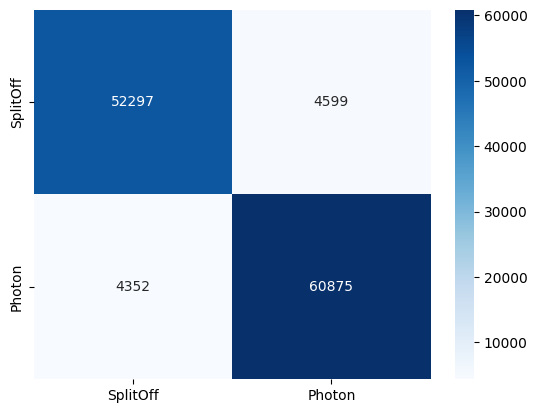

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

test_acc, test_auc, y_true, y_prob = evaluate_gnn(model, test_loader, desc="Test")

cm = confusion_matrix(y_true, (y_prob >= 0.5).astype(int), labels=[0,1])
print(f"Test | acc {test_acc:.4f} | auc {test_auc:.4f}")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["SplitOff","Photon"], yticklabels=["SplitOff","Photon"])
plt.show()

In [26]:
############################################################
# Reference values from https://arxiv.org/pdf/2002.09530
# 85% signal with 60% background rejection
############################################################

# --- Photon efficiency vs split-off rejection utilities (GNN convention) ---

import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix

# GNN convention
# y_true: 0 = SplitOff (background), 1 = Photon (signal)
# y_prob: P(Photon)

def eff_rej_at_threshold(y_true, y_prob, thr):

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)

    # classify photon if probability >= threshold
    y_pred = (y_prob >= thr).astype(int)

    Nsig = np.sum(y_true == 1)
    Nbkg = np.sum(y_true == 0)

    eps_sig = np.sum((y_true == 1) & (y_pred == 1)) / max(1, Nsig)
    rej_bkg = np.sum((y_true == 0) & (y_pred == 0)) / max(1, Nbkg)

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])

    return eps_sig, rej_bkg, cm


def eff_rej_curve(y_true, y_prob):

    # positive class = photon
    fpr, tpr, thrs = roc_curve(y_true, y_prob, pos_label=1)

    eps_sig = tpr          # photon efficiency
    rej_bkg = 1 - fpr      # split-off rejection

    return eps_sig, rej_bkg, thrs


# --- Compute performance curve ---
eps_sig, rej_bkg, thrs = eff_rej_curve(y_true, y_prob)


# --- Working point: photon efficiency ≈ 0.85 ---
target_eps = 0.85

i = int(np.argmin(np.abs(eps_sig - target_eps)))
thr_star = thrs[i]

eps_star, rej_star, cm_star = eff_rej_at_threshold(y_true, y_prob, thr_star)

print(f"Working point (ε_sig≈{target_eps:.2f})")
print(f"threshold = {thr_star:.4f}")
print(f"Photon efficiency = {eps_star:.4f}")
print(f"Split-off rejection = {rej_star:.4f}")

print("\nConfusion matrix")
print("(rows=true, cols=pred)")
print("0=SplitOff, 1=Photon")

print(cm_star)


# --- Performance at default threshold 0.5 ---
eps_05, rej_05, cm_05 = eff_rej_at_threshold(y_true, y_prob, 0.5)

print(f"\nAt threshold 0.5")
print(f"Photon efficiency = {eps_05:.4f}")
print(f"Split-off rejection = {rej_05:.4f}")



Working point (ε_sig≈0.85)
threshold = 0.8326
Photon efficiency = 0.8500
Split-off rejection = 0.9702

Confusion matrix
(rows=true, cols=pred)
0=SplitOff, 1=Photon
[[55198  1698]
 [ 9783 55444]]

At threshold 0.5
Photon efficiency = 0.9333
Split-off rejection = 0.9192


### Figure of Merit Definitions


When optimizing a binary classifier in the presence of signal and background, the **optimal threshold** is often chosen by maximizing a **Figure of Merit (FoM)** that balances **signal efficiency** and **background contamination**.

In this tutorial:

- **Signal** → photon showers  
- **Background** → split-off showers  

---

#### Signal Significance

A commonly used metric is the **signal significance**, defined as

$$
\mathrm{FoM}_{\text{sig}} =
\frac{S}{\sqrt{S + B}}
$$

where

- $S = N_S \, \varepsilon_S$ is the number of **selected signal events**
- $B = N_B \, \varepsilon_B$ is the number of **selected background events**
- $\varepsilon_S$ is the **signal efficiency** (fraction of photons retained)
- $\varepsilon_B$ is the **background efficiency** (fraction of split-offs misidentified as photons)

This FoM estimates the expected **statistical significance** of a signal observation in the presence of background.

---

#### Purity

**Purity** measures how clean the selected sample is, i.e. the fraction of signal among all selected events:

$$
\text{Purity} =
\frac{S}{S + B}
$$

Substituting efficiencies and total counts:

$$
\text{Purity} =
\frac{N_S \varepsilon_S}{N_S \varepsilon_S + N_B \varepsilon_B}
$$

If the dataset signal-to-background ratio is known

$$
\frac{N_S}{N_B}
$$

this becomes

$$
\text{Purity} =
\frac{\varepsilon_S}{\varepsilon_S + \varepsilon_B / (N_S/N_B)}
$$

---

#### Interpretation

- **Signal significance** is useful when the goal is to **maximize discovery potential** (typical in searches for new physics).
- **Purity** is useful when the goal is to obtain a **clean signal sample**, for example when building templates or performing precision measurements.

**FoMs**

In [27]:
import numpy as np
from sklearn.metrics import roc_curve

def find_optimal_threshold(y_true, y_prob, S_over_B=1.0):
    """
    Optimize threshold using signal significance FoM.

    Convention used in this GNN tutorial:
        y_true : 0 = SplitOff (background), 1 = Photon (signal)
        y_prob : P(photon)

    S_over_B : expected signal-to-background ratio in dataset
    """

    # ROC with photon as positive class
    fpr, tpr, thrs = roc_curve(y_true, y_prob, pos_label=1)

    eps_sig = tpr          # photon efficiency
    eps_bkg = fpr          # background efficiency (split-offs misidentified as photons)

    # Signal significance
    fom = eps_sig / np.sqrt(eps_sig + eps_bkg / S_over_B + 1e-12)

    # Purity
    purity = eps_sig / (eps_sig + eps_bkg / S_over_B + 1e-12)

    i_opt = np.argmax(fom)
    thr_opt = thrs[i_opt]

    return {
        "threshold": float(thr_opt),
        "eps_sig": float(eps_sig[i_opt]),
        "rej_bkg": float(1 - eps_bkg[i_opt]),
        "SoverSqrtSB": float(fom[i_opt]),
        "purity": float(purity[i_opt]),
        "curve": {
            "thresholds": thrs,
            "eps_sig": eps_sig,
            "rej_bkg": 1 - eps_bkg,
            "FoM": fom,
            "purity": purity
        },
    }


# --- Run optimization ---
opt = find_optimal_threshold(y_true, y_prob, S_over_B=1.0)

print("Optimal point Summary:")
print(f"  threshold = {opt['threshold']:.3f}")
print(f"  Photon efficiency = {opt['eps_sig']:.3f}")
print(f"  Split-off rejection = {opt['rej_bkg']:.3f}")
print(f"  FoM (S/sqrt(S+B)) = {opt['SoverSqrtSB']:.3f}")
print(f"  Purity = {opt['purity']:.3f}")

Optimal point Summary:
  threshold = 0.534
  Photon efficiency = 0.928
  Split-off rejection = 0.926
  FoM (S/sqrt(S+B)) = 0.927
  Purity = 0.926


**Plot ROC + optimal point**

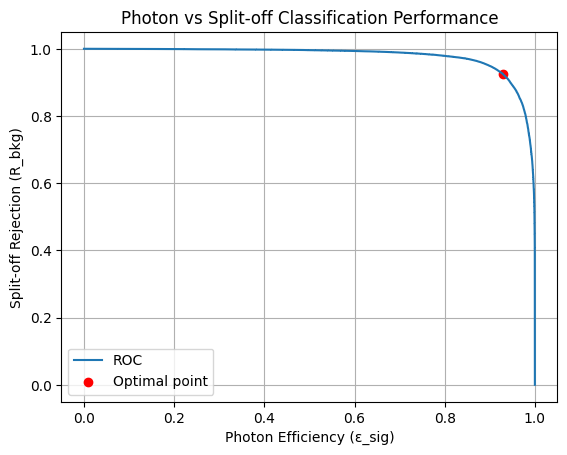

In [28]:
import matplotlib.pyplot as plt

plt.plot(opt["curve"]["eps_sig"], opt["curve"]["rej_bkg"], label="ROC")
plt.scatter(opt["eps_sig"], opt["rej_bkg"], color="r", label="Optimal point")

plt.xlabel("Photon Efficiency (ε_sig)")
plt.ylabel("Split-off Rejection (R_bkg)")
plt.title("Photon vs Split-off Classification Performance")
plt.legend()
plt.grid(True)

plt.show()

**Plot FoM and purity vs threshold**

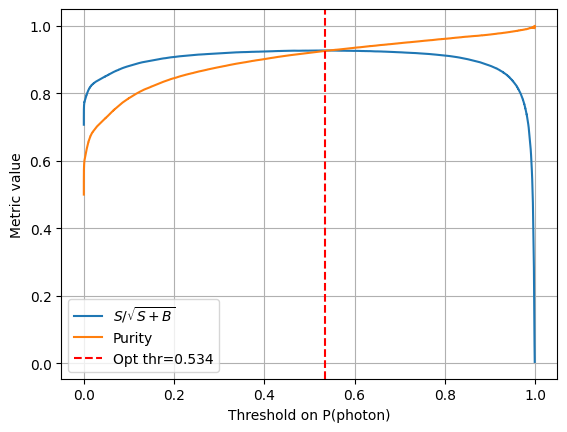

In [29]:
plt.figure()

plt.plot(opt["curve"]["thresholds"], opt["curve"]["FoM"],
         label=r"$S/\sqrt{S+B}$")

plt.plot(opt["curve"]["thresholds"], opt["curve"]["purity"],
         label="Purity")

plt.axvline(opt["threshold"],
            color="r",
            ls="--",
            label=f"Opt thr={opt['threshold']:.3f}")

plt.xlabel("Threshold on P(photon)")
plt.ylabel("Metric value")

plt.legend()
plt.grid(True)

plt.show()

**Energy-dependent Performance**

In [30]:
EBins = [0.100, 0.500, 1.0, 2.0, 4.0]


test_acc, test_auc, y_true, y_prob, showerE = evaluate_gnn(
    model,
    test_loader,
    desc="Test",
    returnShowerE=True
)

Test:   0%|          | 0/239 [00:00<?, ?it/s]

In [31]:
from sklearn.metrics import roc_auc_score, accuracy_score

def metrics_vs_energy(y_true, y_prob, showerE, EBins):
    """
    Compute accuracy and AUC vs shower energy bins.
    """
    EBins = np.asarray(EBins)
    labels = [f"[{EBins[i]:.1f}, {EBins[i+1]:.1f})" for i in range(len(EBins)-1)]
    results = []

    for i in range(len(EBins)-1):
        mask = (showerE >= EBins[i]) & (showerE < EBins[i+1])
        if not np.any(mask):
            results.append((labels[i], np.nan, np.nan, np.sum(mask)))
            continue
        yt = y_true[mask]
        yp = y_prob[mask]
        acc = accuracy_score(yt, yp >= 0.5)
        auc = roc_auc_score(yt, yp) if np.unique(yt).size > 1 else np.nan
        results.append((labels[i], acc, auc, np.sum(mask)))

    return results

In [32]:
bin_results = metrics_vs_energy(y_true, y_prob, showerE, EBins)

print(f"{'E_bin':<15}{'Acc':>10}{'AUC':>10}{'Nevents':>10}")
for label, acc_b, auc_b, n in bin_results:
    print(f"{label:<15}{acc_b:10.3f}{auc_b:10.3f}{n:10d}")

E_bin                 Acc       AUC   Nevents
[0.1, 0.5)          0.889     0.917     46603
[0.5, 1.0)          0.864     0.912     13455
[1.0, 2.0)          0.943     0.905     19009
[2.0, 4.0)          0.983     0.892     32519


[0.5 1.  1.5 2. ]


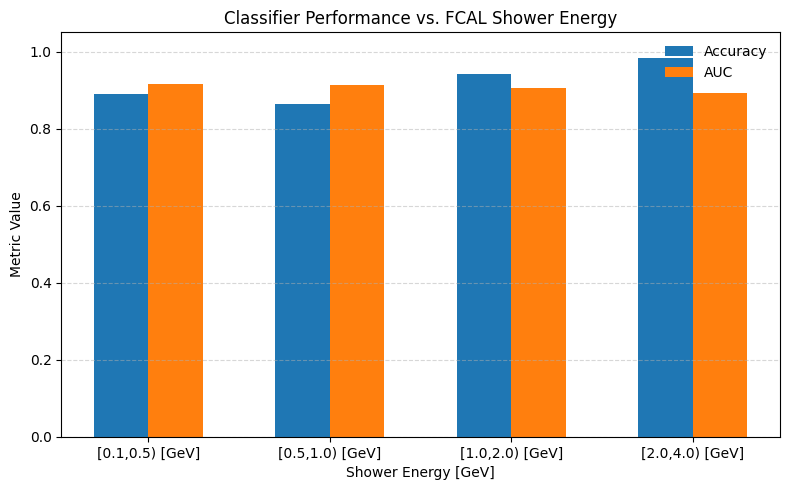

In [33]:
import numpy as np
import matplotlib.pyplot as plt

centers = 0.5 * (np.arange(1, len(EBins)))
print (centers)
width = 0.15  # bar width

accs = [r[1] for r in bin_results]
aucs = [r[2] for r in bin_results]

plt.figure(figsize=(8,5))

# Horizontal offsets for each metric
plt.bar(centers - 1.5*width, accs, width, label="Accuracy")
plt.bar(centers - 0.5*width, aucs, width, label="AUC")

# Styling
plt.xlabel("Shower Energy [GeV]")
plt.ylabel("Metric Value")
plt.title("Classifier Performance vs. FCAL Shower Energy")
plt.xticks(centers - 0.15, [f"[{EBins[i]:.1f},{EBins[i+1]:.1f}) [GeV]" for i in range(len(EBins)-1)])
plt.ylim(0, 1.05)
plt.legend(frameon=False)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Physics Analysis

### Inference on Physics Events

In [34]:
unformatted_omega_data_url = "https://huggingface.co/datasets/AI4EIC/DNP2025-tutorial/resolve/main/unformatted_dataset/OmegaExclusive_100k.root"
omega_dataset_path = download(unformatted_omega_data_url, data_dir)



⬇️  Downloading OmegaExclusive_100k.root from https://huggingface.co/datasets/AI4EIC/DNP2025-tutorial/resolve/main/unformatted_dataset/OmegaExclusive_100k.root



OmegaExclusive_100k.root: 86.0MB [00:02, 34.0MB/s]                            


✅ Download complete: data/OmegaExclusive_100k.root



✅ Loaded ω events: 97525


Running ω-event inference (unformatted ROOT):   0%|          | 0/97525 [00:00<?, ?it/s]/tmp/ipykernel_14068/1340404881.py:226: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_omega  = float(fourvec_mass(p4_omega))
/tmp/ipykernel_14068/1340404881.py:241: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_omega  = float(fourvec_mass(p4_omega))
/tmp/ipykernel_14068/1340404881.py:252: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_omega  = float(fourvec_mass(p4_omega))
R


Raw entry counts:
  bench: N=  595673  sum(weights)=595673.00
  rect : N=  104166  sum(weights)=68834.00
  gnn  : N=  100352  sum(weights)=68324.00


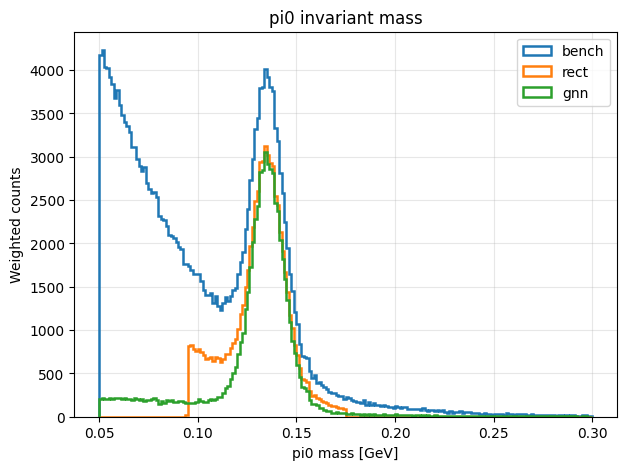

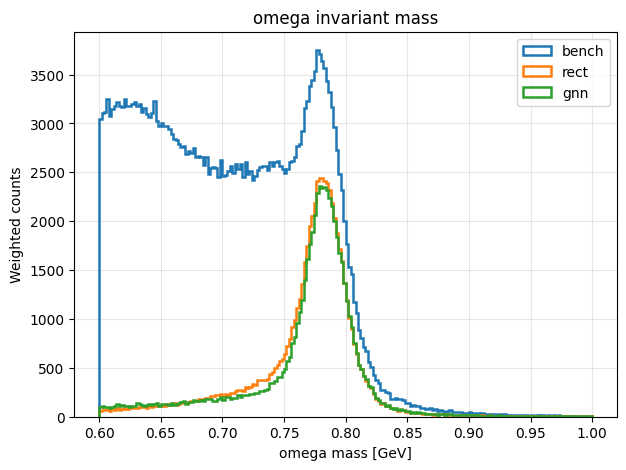


GNN photon-score statistics (sampled showers):
  mean: 0.4355287253856659
  std : 0.437677800655365
  min : 9.766842716529833e-12
  max : 0.9997170567512512


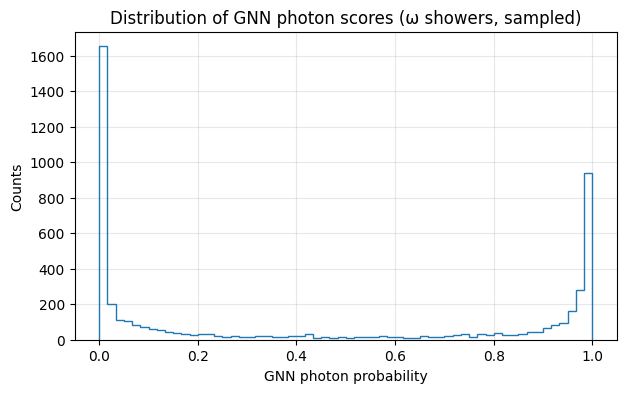

In [35]:
# --- ω physics-events analysis with your trained SmallGNN on UNFORMATTED ROOT ---

import uproot, awkward as ak, numpy as np
import torch
from torch_geometric.data import Data
from itertools import combinations
from tqdm import tqdm
import matplotlib.pyplot as plt

# ======================
# Assumptions from above
# ======================
# - model : trained SmallGNN
# - DEVICE : "cuda"/"cpu"
# - shower_to_graph(), build_edges_8n(), logE_norm() already defined exactly as in your training code
# - omega_dataset_path points to OmegaExclusive_100k.root

PI0_MASS = 0.1349768  # GeV
FCAL_NROW, FCAL_NCOL = 59, 59

# -------------------------
# Helpers: TLorentzVector IO
# -------------------------

import numpy as np
import awkward as ak

def _to_numpy_scalar_or_array(x):
    """
    Convert awkward/np/python scalar-or-array to numpy array or float.
    """
    # If it's an awkward array/record field, convert to numpy
    try:
        return ak.to_numpy(x)
    except Exception:
        return np.asarray(x)

def _tlv_to_p4(rec):
    """
    Robustly decode ROOT TLorentzVector as read by uproot/awkward.

    Supports:
      - TLorentzVector with top-level fields: fE, fP
        where fP is either:
          * a nested TVector3 record (fields fX,fY,fZ or X,Y,Z etc.)
          * a length-3 array [px,py,pz]
    Returns:
      numpy array shape (4,) for scalars, or (...,4) for arrays
      with ordering [px,py,pz,E]
    """
    fields = set(getattr(rec, "fields", []))
    if "fE" not in fields or "fP" not in fields:
        raise RuntimeError(f"Expected TLorentzVector with fields fE and fP. Got fields: {sorted(list(fields))}")

    E = _to_numpy_scalar_or_array(rec["fE"])
    P = rec["fP"]

    # Case A: fP is a nested record (TVector3-like)
    p_fields = set(getattr(P, "fields", []))
    # ROOT TVector3 commonly uses fX,fY,fZ (or sometimes X,Y,Z)
    if {"fX", "fY", "fZ"}.issubset(p_fields):
        px = _to_numpy_scalar_or_array(P["fX"])
        py = _to_numpy_scalar_or_array(P["fY"])
        pz = _to_numpy_scalar_or_array(P["fZ"])
    elif {"X", "Y", "Z"}.issubset(p_fields):
        px = _to_numpy_scalar_or_array(P["X"])
        py = _to_numpy_scalar_or_array(P["Y"])
        pz = _to_numpy_scalar_or_array(P["Z"])
    elif {"x", "y", "z"}.issubset(p_fields):
        px = _to_numpy_scalar_or_array(P["x"])
        py = _to_numpy_scalar_or_array(P["y"])
        pz = _to_numpy_scalar_or_array(P["z"])
    else:
        # Case B: fP is a numeric array of shape (...,3)
        P_np = _to_numpy_scalar_or_array(P)
        P_np = np.asarray(P_np)
        if P_np.shape == (3,):              # single vector
            px, py, pz = P_np[0], P_np[1], P_np[2]
        elif P_np.ndim >= 1 and P_np.shape[-1] == 3:
            px, py, pz = np.moveaxis(P_np, -1, 0)
        else:
            raise RuntimeError(
                "Could not decode TLorentzVector.fP as a TVector3 record or (...,3) array.\n"
                f"Top fields: {sorted(list(fields))}\n"
                f"fP fields: {sorted(list(p_fields)) if p_fields else 'None'}\n"
                f"fP numpy shape: {getattr(P_np, 'shape', None)}"
            )

    # Stack to p4 = [px,py,pz,E] with broadcasting
    px = np.asarray(px)
    py = np.asarray(py)
    pz = np.asarray(pz)
    E  = np.asarray(E)

    # Ensure same shape via numpy broadcasting
    p4 = np.stack([px, py, pz, E], axis=-1).astype(np.float32, copy=False)
    return p4


def fourvec_mass(p4):
    px, py, pz, E = np.moveaxis(p4, -1, 0)
    m2 = E**2 - (px**2 + py**2 + pz**2)
    m2 = np.maximum(m2, 0.0)
    return np.sqrt(m2)

def combine_p4(p4a, p4b):
    return p4a + p4b

# ---------------------------------------
# Derive isNearBorder from shower centroid
# ---------------------------------------
def infer_isNearBorder_from_hits(rows, cols, energies, margin=2, eps=1e-9):
    if len(energies) == 0:
        return True
    Eraw = np.asarray(energies, dtype=np.float32)
    rows = np.asarray(rows, dtype=np.float32)
    cols = np.asarray(cols, dtype=np.float32)

    Esum = float(Eraw.sum()) + eps
    r_c = float((rows * Eraw).sum() / Esum)
    c_c = float((cols * Eraw).sum() / Esum)

    near = (
        (r_c < margin) or (r_c > (FCAL_NROW - 1 - margin)) or
        (c_c < margin) or (c_c > (FCAL_NCOL - 1 - margin))
    )
    return bool(near)

# -----------------------------------------
# Build one shower graph consistent w/ train
# -----------------------------------------
def omega_shower_to_graph(rows, cols, energies, showerE_scalar, numBlocks_scalar):
    """
    Mirrors your training graph:
      x: [row_n, col_n, E_logscaled, logEraw, Efrac, dx, dy, r]  (8)
      g: [showerE, numBlocks, isNearBorder]                     (3)
    """
    rows = np.asarray(rows, dtype=np.int64)
    cols = np.asarray(cols, dtype=np.int64)
    Eraw = np.asarray(energies, dtype=np.float32)
    if Eraw.size == 0:
        return None

    # same border proxy for g
    near = infer_isNearBorder_from_hits(rows, cols, Eraw)

    data = shower_to_graph(
        rows, cols, Eraw,
        showerE=float(showerE_scalar),
        numBlocks=int(numBlocks_scalar),
        isNearBorder=near
    )
    if data is None:
        return None

    # IMPORTANT: for your model, data.g must be 2D: (1,3)
    data.g = torch.tensor([[float(showerE_scalar), float(numBlocks_scalar), float(near)]], dtype=torch.float32)

    return data

# -------------------------
# GNN inference: one shower
# -------------------------
@torch.inference_mode()
def gnn_photon_prob_for_shower(model, data: Data, device: str):
    """
    Returns P(photon) for a single shower graph.
    """
    if data is None:
        return 0.0
    data = data.to(device)
    # make a single-graph batch vector if missing
    if not hasattr(data, "batch") or data.batch is None:
        data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)

    logits = model(data)  # (1,2) or (B,2)
    prob_photon = torch.softmax(logits, dim=1)[0, 1].item()
    return float(prob_photon)

# -----------------------------
# Event-level ω reconstruction
# -----------------------------
def analyze_event_omega_gnn(ev, model, device, thr_photon=0.2, rect_mass_window=0.04):
    """
    Modes:
      - gnn   : keep showers with P(photon) >= thr_photon
      - rect  : select pairs with |m(pi0)-m(pi0)| < rect_mass_window
      - bench : all pairs
    Returns dict of lists: (m_pi0, m_omega, weight)
    """
    results = {"gnn": [], "rect": [], "bench": []}

    # charged tracks (reconstructed)
    p4_pi_plus  = _tlv_to_p4(ev["thrownPiPlus"]) #in the other tutorial, used thrownPiPlus / used here reconPiPlus
    p4_pi_minus = _tlv_to_p4(ev["thrownPiMinus"])

    # showers p4 from FCAL neutral shower
    shower_p4 = ev["shower_p4"]          # (nShowers,4)
    shower_hits = ev["shower_hits"]      # list of per-shower (rows,cols,energies)
    showerE_vec = ev["showerE"]          # (nShowers,)
    numBlocks_vec = ev["numBlocks"]      # (nShowers,)

    nShowers = int(ev["nShowers"])
    if nShowers < 2:
        return results

    # --- per-shower GNN score
    probs = []
    for s in range(nShowers):
        rows_s, cols_s, en_s = shower_hits[s]
        data = omega_shower_to_graph(rows_s, cols_s, en_s, showerE_vec[s], numBlocks_vec[s])
        p = gnn_photon_prob_for_shower(model, data, device)
        probs.append(p)

    good = [i for i, p in enumerate(probs) if p >= thr_photon]

    pairs = list(combinations(range(nShowers), 2))
    if not pairs:
        return results

    # --- bench (all)
    for (i, j) in pairs:
        p4_pi0   = combine_p4(shower_p4[i], shower_p4[j])
        m_pi0    = float(fourvec_mass(p4_pi0))
        p4_omega = combine_p4(p4_pi0, combine_p4(p4_pi_plus, p4_pi_minus))
        m_omega  = float(fourvec_mass(p4_omega))
        results["bench"].append((m_pi0, m_omega, 1.0))

    # --- rect: |m(pi0)-m0| cut
    rect_pairs = []
    for (i, j) in pairs:
        m_pi0 = float(fourvec_mass(combine_p4(shower_p4[i], shower_p4[j])))
        if abs(m_pi0 - PI0_MASS) < rect_mass_window:
            rect_pairs.append((i, j))
    if rect_pairs:
        Nrect = len(rect_pairs)
        for (i, j) in rect_pairs:
            p4_pi0   = combine_p4(shower_p4[i], shower_p4[j])
            m_pi0    = float(fourvec_mass(p4_pi0))
            p4_omega = combine_p4(p4_pi0, combine_p4(p4_pi_plus, p4_pi_minus))
            m_omega  = float(fourvec_mass(p4_omega))
            results["rect"].append((m_pi0, m_omega, 1.0 / Nrect))

    # --- gnn: both showers pass threshold
    gnn_pairs = [p for p in pairs if (p[0] in good and p[1] in good)]
    if gnn_pairs:
        N = len(gnn_pairs)
        for (i, j) in gnn_pairs:
            p4_pi0   = combine_p4(shower_p4[i], shower_p4[j])
            m_pi0    = float(fourvec_mass(p4_pi0))
            p4_omega = combine_p4(p4_pi0, combine_p4(p4_pi_plus, p4_pi_minus))
            m_omega  = float(fourvec_mass(p4_omega))
            results["gnn"].append((m_pi0, m_omega, 1.0 / N))

    return results, probs

# -------------------------
# Load ω tree + run analysis
# -------------------------
omega_tree = uproot.open(omega_dataset_path)["OmegaSampleTree"]

# NOTE: TLorentzVector branches are read as awkward records.
branches = [
    "thrownPiPlus", "thrownPiMinus",
    "reconPiPlus", "reconPiMinus",
    "nShowers",
    "rows", "cols", "energies",
    "startIndexPerShower", "nHitsPerShower",
    "showerE", "numBlocks",
    "FCALNeutralShowerPx", "FCALNeutralShowerPy", "FCALNeutralShowerPz", "FCALNeutralShowerE",
]
arr = omega_tree.arrays(branches, library="ak")

Nevt = len(arr["nShowers"])
print("✅ Loaded ω events:", Nevt)

model = model.to(DEVICE).eval()

# Choose a *reasonable* default threshold for event-level selection.
# IMPORTANT: For event-level ω, thr=0.5 may be far too strict; start with 0.1–0.2 and scan later.
THR_PHOTON   = 0.15
PI0_MASS_CUT = 0.04

all_results = {"bench": [], "rect": [], "gnn": []}
score_samples = []

for ievt in tqdm(range(Nevt), desc="Running ω-event inference (unformatted ROOT)"):
    nShow = int(arr["nShowers"][ievt])
    if nShow < 2:
        continue

    # Flattened hit arrays for the whole event
    rows_evt = ak.to_numpy(arr["rows"][ievt]).astype(np.int64, copy=False)
    cols_evt = ak.to_numpy(arr["cols"][ievt]).astype(np.int64, copy=False)
    en_evt   = ak.to_numpy(arr["energies"][ievt]).astype(np.float32, copy=False)

    start = ak.to_numpy(arr["startIndexPerShower"][ievt]).astype(np.int64, copy=False)
    nhits = ak.to_numpy(arr["nHitsPerShower"][ievt]).astype(np.int64, copy=False)

    showerE_vec   = ak.to_numpy(arr["showerE"][ievt]).astype(np.float32, copy=False)
    numBlocks_vec = ak.to_numpy(arr["numBlocks"][ievt]).astype(np.int32, copy=False)

    # Shower p4 directly from branches
    px = ak.to_numpy(arr["FCALNeutralShowerPx"][ievt]).astype(np.float32, copy=False)
    py = ak.to_numpy(arr["FCALNeutralShowerPy"][ievt]).astype(np.float32, copy=False)
    pz = ak.to_numpy(arr["FCALNeutralShowerPz"][ievt]).astype(np.float32, copy=False)
    E  = ak.to_numpy(arr["FCALNeutralShowerE"][ievt]).astype(np.float32, copy=False)
    shower_p4 = np.stack([px, py, pz, E], axis=1)  # (nShowers,4)

    # Per-shower hit slicing (rows/cols/energies)
    shower_hits = []
    for s in range(nShow):
        a = int(start[s])
        b = a + int(nhits[s])
        shower_hits.append((rows_evt[a:b], cols_evt[a:b], en_evt[a:b]))

    # Build event dict
    ev = dict(
        thrownPiPlus=arr["thrownPiPlus"][ievt],
        thrownPiMinus=arr["thrownPiMinus"][ievt],
        reconPiPlus=arr["reconPiPlus"][ievt],
        reconPiMinus=arr["reconPiMinus"][ievt],
        nShowers=nShow,
        shower_p4=shower_p4,
        shower_hits=shower_hits,
        showerE=showerE_vec,
        numBlocks=numBlocks_vec,
    )

    out, probs = analyze_event_omega_gnn(ev, model, DEVICE, thr_photon=THR_PHOTON, rect_mass_window=PI0_MASS_CUT)
    for k in all_results:
        all_results[k].extend(out[k])

    # keep a small sample of scores for diagnostics
    if len(score_samples) < 5000:
        score_samples.extend(probs)

# -------------------------
# Print raw selection stats
# -------------------------
def _sumw(lst):
    return float(np.sum([x[2] for x in lst])) if len(lst) else 0.0

print("\nRaw entry counts:")
for k in ["bench", "rect", "gnn"]:
    print(f"  {k:5s}: N={len(all_results[k]):8d}  sum(weights)={_sumw(all_results[k]):.2f}")

# -------------------------
# Plot mass spectra overlays
# -------------------------
def plot_mass_spectrum(all_results, key="pi0", nbins=200, mass_range=(0.05, 0.30)):
    plt.figure(figsize=(7,5))
    for label in ["bench", "rect", "gnn"]:
        masses  = [m[0] if key=="pi0" else m[1] for m in all_results[label]]
        weights = [m[2] for m in all_results[label]]
        plt.hist(masses, bins=nbins, range=mass_range, histtype="step",
                 linewidth=1.8, label=label, weights=weights)
    plt.xlabel(f"{key} mass [GeV]")
    plt.ylabel("Weighted counts")
    plt.title(f"{key} invariant mass")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_mass_spectrum(all_results, key="pi0",   nbins=200, mass_range=(0.05, 0.30))
plot_mass_spectrum(all_results, key="omega", nbins=200, mass_range=(0.60, 1.00))

# -------------------------
# Diagnostic: score spectrum
# -------------------------
score_samples = np.asarray(score_samples, dtype=np.float32)
if score_samples.size:
    print("\nGNN photon-score statistics (sampled showers):")
    print("  mean:", float(score_samples.mean()))
    print("  std :", float(score_samples.std()))
    print("  min :", float(score_samples.min()))
    print("  max :", float(score_samples.max()))
    plt.figure(figsize=(7,4))
    plt.hist(score_samples, bins=60, range=(0,1), histtype="step")
    plt.xlabel("GNN photon probability")
    plt.ylabel("Counts")
    plt.title("Distribution of GNN photon scores (ω showers, sampled)")
    plt.grid(True, alpha=0.3)
    plt.show()

**Note:** The GNN-based photon identification achieves a performance comparable to (or slightly better than) the traditional π⁰ mass window selection. Importantly, the classifier relies solely on calorimeter shower topology and does not use the π⁰ invariant mass as an input. When applied to ω → π⁺π⁻π⁰ events, the GNN selection reproduces the expected π⁰ and ω mass peaks while significantly reducing combinatorial background relative to the inclusive benchmark

/tmp/ipykernel_14068/746976919.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  yield_sig = np.trapz(sig, xfine)


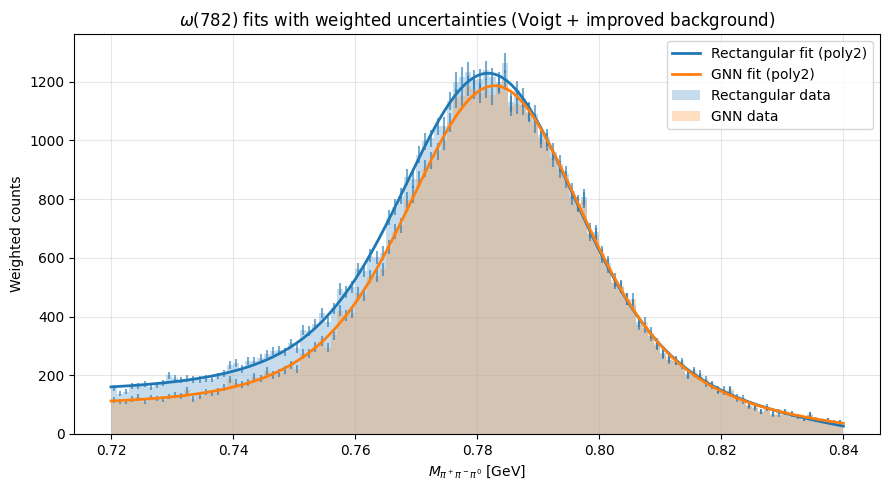


[Rectangular]  model=Voigt+poly2  range=(0.72, 0.84)  nbins=120
  m0        = 0.781994 ± 0.000097 GeV
  gamma     = 19.31 ± 5.00 MeV
  sigma     = 10.31 ± 1.23 MeV
  Yield     = 49.9 (a.u., integral of signal in fit window)
  chi2/ndf  = 131.2 / 113 = 1.161
  p-value   = 0.116

[GNN]  model=Voigt+poly2  range=(0.72, 0.84)  nbins=120
  m0        = 0.782977 ± 0.000098 GeV
  gamma     = 20.63 ± 4.63 MeV
  sigma     = 9.87 ± 1.19 MeV
  Yield     = 50.4 (a.u., integral of signal in fit window)
  chi2/ndf  = 94.3 / 113 = 0.835
  p-value   = 0.899


In [36]:
# --- Improved ω mass fits with proper weighted uncertainties + better background ---

%pip -q install scipy > /dev/null

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import wofz
from scipy.stats import chi2

# ------------------------
# Signal: Voigt (BW ⊗ Gauss)
# ------------------------
def voigt_pdf(x, A, m0, gamma, sigma):
    """
    A = overall amplitude (not exactly yield unless integrated)
    m0 = peak position
    gamma = Lorentzian FWHM-ish parameter used as gamma in Voigt definition (GeV)
    sigma = Gaussian sigma (GeV)
    """
    z = ((x - m0) + 1j * gamma / 2.0) / (sigma * np.sqrt(2.0))
    return A * np.real(wofz(z)) / (sigma * np.sqrt(2.0 * np.pi))

# ------------------------
# Background options
# ------------------------
def bkg_poly2(x, c0, c1, c2):
    return c0 + c1*x + c2*(x**2)

def bkg_exp(x, c0, c1, c2):
    # positive-ish exponential + offset: c0 + c1 * exp(c2 x)
    return c0 + c1 * np.exp(c2 * x)

# Combined models
def model_voigt_poly2(x, A, m0, gamma, sigma, c0, c1, c2):
    return voigt_pdf(x, A, m0, gamma, sigma) + bkg_poly2(x, c0, c1, c2)

def model_voigt_exp(x, A, m0, gamma, sigma, c0, c1, c2):
    return voigt_pdf(x, A, m0, gamma, sigma) + bkg_exp(x, c0, c1, c2)

# ------------------------
# Histogram w/ proper weighted uncertainties
# ------------------------
def hist_w_sumw2(masses, weights, nbins, fit_range):
    masses = np.asarray(masses, dtype=np.float64)
    weights = np.ones_like(masses) if weights is None else np.asarray(weights, dtype=np.float64)

    hist, bins = np.histogram(masses, bins=nbins, range=fit_range, weights=weights)
    sumw2, _   = np.histogram(masses, bins=nbins, range=fit_range, weights=weights**2)
    centers = 0.5*(bins[1:] + bins[:-1])

    # sigma for weighted hist
    sigma = np.sqrt(np.maximum(sumw2, 1e-12))
    return hist, sigma, centers, bins

# ------------------------
# Fit driver
# ------------------------
def fit_omega_spectrum(masses, weights=None, label="sel",
                       nbins=120, fit_range=(0.72, 0.84),
                       bkg="poly2", min_rel_err=1e-6):
    """
    bkg: "poly2" or "exp"
    fit_range: recommend (0.72, 0.84) first; widen later if needed
    """

    y, yerr, x, bins = hist_w_sumw2(masses, weights, nbins=nbins, fit_range=fit_range)

    # Drop bins with ~0 uncertainty (can happen if no entries)
    mask = yerr > (min_rel_err * np.max(yerr))
    xfit, yfit, sfit = x[mask], y[mask], yerr[mask]

    if xfit.size < 12:
        raise RuntimeError(f"[{label}] Too few populated bins to fit. Try fewer bins or wider range.")

    # Initial guesses (robust-ish)
    A0 = float(np.max(yfit))
    m00 = 0.782
    gamma0 = 0.0085   # ~ ω natural width ~8.5 MeV
    sigma0 = 0.012    # detector smearing guess (12 MeV)

    # background init
    c00 = float(np.median(yfit))
    c10 = 0.0
    c20 = 0.0

    if bkg == "poly2":
        f = model_voigt_poly2
        p0 = [A0, m00, gamma0, sigma0, c00, c10, c20]
        bounds = (
            [0.0,   0.76,  0.001, 0.002, -np.inf, -np.inf, -np.inf],
            [np.inf,0.80,  0.050, 0.050,  np.inf,  np.inf,  np.inf],
        )
    elif bkg == "exp":
        f = model_voigt_exp
        # exp params: c0 + c1 exp(c2 x)
        p0 = [A0, m00, gamma0, sigma0, c00, max(1.0, 0.1*c00), -5.0]
        bounds = (
            [0.0,   0.76,  0.001, 0.002, -np.inf, -np.inf, -50.0],
            [np.inf,0.80,  0.050, 0.050,  np.inf,  np.inf,  50.0],
        )
    else:
        raise ValueError("bkg must be 'poly2' or 'exp'")

    popt, pcov = curve_fit(
        f, xfit, yfit, p0=p0, bounds=bounds,
        sigma=sfit, absolute_sigma=True, maxfev=40000
    )
    perr = np.sqrt(np.diag(pcov))

    # Goodness-of-fit (using fit bins only)
    ymodel = f(xfit, *popt)
    chi2_val = np.sum(((yfit - ymodel)/sfit)**2)
    ndf = xfit.size - len(popt)
    pval = chi2.sf(chi2_val, max(ndf, 1))

    # Yield = integral of signal component over fit range
    xfine = np.linspace(fit_range[0], fit_range[1], 4000)
    A, m0, gamma, sigma_g = popt[:4]
    sig = voigt_pdf(xfine, A, m0, gamma, sigma_g)
    yield_sig = np.trapz(sig, xfine)

    return {
        "label": label,
        "bkg": bkg,
        "fit_range": fit_range,
        "nbins": nbins,
        "popt": popt,
        "perr": perr,
        "pcov": pcov,
        "chi2": float(chi2_val),
        "ndf": int(ndf),
        "pval": float(pval),
        "yield": float(yield_sig),
        "hist": y,
        "err": yerr,
        "centers": x,
        "bins": bins,
        "model_fn": f,
    }

def plot_fit(result, alpha_data=0.25):
    x = result["centers"]
    y = result["hist"]
    e = result["err"]
    f = result["model_fn"]
    popt = result["popt"]
    bw = result["bins"][1] - result["bins"][0]

    # show data with uncertainties (weighted)
    plt.bar(x, y, width=bw, alpha=alpha_data, label=f"{result['label']} data")
    plt.errorbar(x, y, yerr=e, fmt="none", capsize=0, alpha=0.6)

    # smooth fit curve
    xx = np.linspace(result["fit_range"][0], result["fit_range"][1], 2000)
    plt.plot(xx, f(xx, *popt), lw=2, label=f"{result['label']} fit ({result['bkg']})")

# ------------------------
# Run on your selections: all_results must exist with keys "gnn","rect","bench"
# ------------------------
range_fit = (0.72, 0.84)   # <-- start tight; if stable, expand later
nbins = 120
bkg_model = "poly2"        # try "exp" if poly2 still struggles

m_gnn  = [t[1] for t in all_results["gnn"]]
w_gnn  = [t[2] for t in all_results["gnn"]]
m_rect = [t[1] for t in all_results["rect"]]
w_rect = [t[2] for t in all_results["rect"]]

fit_gnn  = fit_omega_spectrum(m_gnn,  w_gnn,  label="GNN",        nbins=nbins, fit_range=range_fit, bkg=bkg_model)
fit_rect = fit_omega_spectrum(m_rect, w_rect, label="Rectangular",nbins=nbins, fit_range=range_fit, bkg=bkg_model)

plt.figure(figsize=(9,5))
plot_fit(fit_rect)
plot_fit(fit_gnn)
plt.xlabel(r"$M_{\pi^+\pi^-\pi^0}$ [GeV]")
plt.ylabel("Weighted counts")
plt.title(r"$\omega(782)$ fits with weighted uncertainties (Voigt + improved background)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

def print_summary(res):
    A,m0,gamma,sigma = res["popt"][:4]
    dA,dm0,dg,ds = res["perr"][:4]
    print(f"\n[{res['label']}]  model=Voigt+{res['bkg']}  range={res['fit_range']}  nbins={res['nbins']}")
    print(f"  m0        = {m0:.6f} ± {dm0:.6f} GeV")
    print(f"  gamma     = {gamma*1000:.2f} ± {dg*1000:.2f} MeV")
    print(f"  sigma     = {sigma*1000:.2f} ± {ds*1000:.2f} MeV")
    print(f"  Yield     = {res['yield']:.1f} (a.u., integral of signal in fit window)")
    print(f"  chi2/ndf  = {res['chi2']:.1f} / {res['ndf']} = {res['chi2']/max(1,res['ndf']):.3f}")
    print(f"  p-value   = {res['pval']:.3g}")

print_summary(fit_rect)
print_summary(fit_gnn)

### Meaning of the Voigt Fit Parameters

The ω mass peak is modeled using a **Voigt function**, which is the convolution of a **Breit–Wigner distribution** (intrinsic particle width) and a **Gaussian distribution** (detector resolution).

- **Γ (Gamma)** — *Intrinsic decay width of the particle*.  
  This is a **physical property of the resonance** related to its lifetime through  
  \(\Gamma = \hbar / \tau\).  
  For the ω meson, the natural width is about **8.5 MeV**.

- **σ (Sigma)** — *Detector resolution*.  
  This represents the **Gaussian smearing introduced by the detector and reconstruction**, such as calorimeter energy resolution, tracking resolution, and π⁰ reconstruction uncertainties.


### Interpretation of p-values in χ² goodness-of-fit tests

If the model is correct and the uncertainties are correct, what is the probability of observing a χ² at least this large just from statistical fluctuations?

$$
p = p(\chi^2 \leq \chi^{2}_{obs}| \text{model true})
$$


| p-value range | Interpretation |
|---------------|----------------|
| **p < 0.001** | Model very unlikely to describe the data (fit clearly poor) |
| **0.001 – 0.01** | Suspicious: model may be inadequate or uncertainties underestimated |
| **0.01 – 0.05** | Borderline fit |
| **0.05 – 0.95** | Acceptable / good fit |
| **p > 0.95** | Residuals smaller than expected — uncertainties may be overestimated |
